In [7]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity

In [8]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [9]:
class network_wake(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, num_layers=2, num_layers_sleep=2):
        super(network_wake, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, hw=None):
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out)
        
        return out, hw

In [10]:
class network_sleep(nn.Module):
    def __init__(self, input_size, hidden_sleep_size, num_layers=1):
        super(network_sleep, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_sleep_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, len(tokens))

    def forward(self, x, hs=None):
        if hs == None:
            out, hs = self.rnn(x)
        else:
            out, hs = self.rnn(x, hs)

        out = self.sleep_fc(out)
        
        return out, hs

In [11]:
class compressor(nn.Module):
    def __init__(self, input_size, hidden_compressor_size, num_layers=1):
        super(compressor, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_compressor_size, num_layers, nonlinearity='relu', batch_first=True)
        self.compressor_fc = nn.Linear(hidden_compressor_size, 2)

    def forward(self, x, hc=None):
        if hc == None:
            out, hc = self.rnn(x)
        else:
            out, hc = self.rnn(x, hc)

        out = self.compressor_fc(out)
        
        return out, hc

In [12]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [13]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=1):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, 5*len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))
        last_visit1 = one_hot_encoded[0]
        last_visit2 = one_hot_encoded[1]
        current_visit = one_hot_encoded[2]
        flag = False
        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,-len(tokens):] = \
                        one_hot_encoded[ii+jj+kk,:]
                    self.X[ii,jj,:7] = \
                        last_visit2.copy()
                    self.X[ii,jj,7:14] = \
                        np.array([0,0,0,0,0,0,1])
                    self.X[ii,jj,14:21] = \
                        last_visit1.copy()
                    self.X[ii,jj,21:28] = \
                        np.array([0,0,0,0,0,0,1])
                    
                    # print(data[ii+jj+kk], data[ii+jj+kk] == 'G')
                    if data[ii+jj+kk] == 'G':
                        last_visit2 = last_visit1.copy()
                        last_visit1 = current_visit.copy()
                        flag = True 
                    # print(data[ii+jj+kk] == 'A' or data[ii+jj+kk] == 'B' or data[ii+jj+kk] == 'C')
                    if flag:
                        if data[ii+jj+kk] == 'A' or data[ii+jj+kk] == 'B' or data[ii+jj+kk] == 'C':
                            # print(data[ii+jj+kk], 'condition1')
                            current_visit = one_hot_encoded[ii+jj+kk,:].copy()
                            flag = False
                            
                        elif data[ii+jj+kk] == 'D' or data[ii+jj+kk] == 'E' or data[ii+jj+kk] == 'F':
                            # print(data[ii+jj+kk], 'condition2')
                            current_visit = one_hot_encoded[ii+jj+kk,:].copy()
                            flag = False 

            # print(last_visit1, last_visit2, current_visit, flag)       
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [14]:
class Dataset_converter_compressor(Dataset):
    def __init__(self, data, mask):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, len(tokens)))
        self.y = np.zeros((total_sample-2, 2))
        for ii in range(total_sample-2):
            token = data[ii]
            self.X[ii, ord(token)-65] = 1 
            self.y[ii,mask[ii]] = 1
            

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [87]:
### initial training ###
total_samples = 60000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 50
hidden_compressor_size = 5
hidden_sleep_size = 50
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = 5*len(tokens)*working_memory
additional_input = torch.zeros((1,1,4*len(tokens)))

lr = 4e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members) #
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = network_wake(input_size, hidden_wake_size, hidden_sleep_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    # X = torch.cat((additional_input, X), dim=2)
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X)
    else:
        predicted_y, hidden = network1(X, hw=mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 2.0299, accuracy: 0.2110
Iter : 2001, loss: 2.6507, accuracy: 0.3270
Iter : 3001, loss: 1.5595, accuracy: 0.3650
Iter : 4001, loss: 1.6765, accuracy: 0.5200
Iter : 5001, loss: 2.4497, accuracy: 0.6500
Iter : 6001, loss: 2.2177, accuracy: 0.7070
Iter : 7001, loss: 1.7191, accuracy: 0.7220
Iter : 8001, loss: 2.2993, accuracy: 0.7390
Iter : 9001, loss: 2.9573, accuracy: 0.7360
Iter : 10001, loss: 1.2203, accuracy: 0.7420
Iter : 11001, loss: 0.4396, accuracy: 0.7380
Iter : 12001, loss: 2.0580, accuracy: 0.7540
Iter : 13001, loss: 2.1210, accuracy: 0.7530
Iter : 14001, loss: 1.5029, accuracy: 0.7520
Iter : 15001, loss: 0.9460, accuracy: 0.7530
Iter : 16001, loss: 1.4147, accuracy: 0.7710
Iter : 17001, loss: 1.6767, accuracy: 0.7530
Iter : 18001, loss: 2.6484, accuracy: 0.7500
Iter : 19001, loss: 1.3884, accuracy: 0.7470
Iter : 20001, loss: 1.2351, accuracy: 0.7510
Iter : 21001, loss: 1.8135, accuracy: 0.7580
Iter : 22001, loss: 1.4433, accuracy: 0.7630
Iter : 23001, loss:

In [93]:
for ii in range(5):
    print(data_set[20][0][0][ii*7:(ii+1)*7])

print('\n')

for ii in range(5):
    print(data_set[25][0][0][ii*7:(ii+1)*7])

print('\n')

for ii in range(5):
    print(data_set[30][0][0][ii*7:(ii+1)*7])

tensor([0., 0., 0., 0., 1., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 1.])
tensor([1., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 1.])
tensor([0., 0., 0., 0., 1., 0., 0.])


tensor([1., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 1.])
tensor([0., 0., 0., 0., 1., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 1.])
tensor([0., 0., 0., 1., 0., 0., 0.])


tensor([0., 0., 0., 0., 1., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 1.])
tensor([0., 0., 0., 1., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 1.])
tensor([0., 0., 0., 0., 1., 0., 0.])


In [94]:
class network_wake2(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, num_layers=2, num_layers_sleep=2):
        super(network_wake2, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(4*len(tokens), len(tokens))
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, x_, hw=None):
        x = x + self.sleep_fc(x_)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out)
        
        return out, hw

In [95]:
### initial training ###
total_samples = 60000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 50
hidden_compressor_size = 5
hidden_sleep_size = 50
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = len(tokens)*working_memory

lr = 6e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members) #
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = network_wake2(input_size, hidden_wake_size, hidden_sleep_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    # X = torch.cat((additional_input, X), dim=2)
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X[:,:,-7:], X[:,:,:-7])
    else:
        predicted_y, hidden = network1(X[:,:,-7:], X[:,:,:-7], hw=mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 2.2324, accuracy: 0.2660
Iter : 2001, loss: 2.7961, accuracy: 0.4270
Iter : 3001, loss: 0.6950, accuracy: 0.6140
Iter : 4001, loss: 1.0873, accuracy: 0.6660
Iter : 5001, loss: 2.1855, accuracy: 0.7110
Iter : 6001, loss: 2.4997, accuracy: 0.7330
Iter : 7001, loss: 0.6567, accuracy: 0.7340
Iter : 8001, loss: 2.2563, accuracy: 0.7300
Iter : 9001, loss: 2.4973, accuracy: 0.7300
Iter : 10001, loss: 1.3090, accuracy: 0.7370
Iter : 11001, loss: 0.9142, accuracy: 0.7430
Iter : 12001, loss: 1.0824, accuracy: 0.7520
Iter : 13001, loss: 1.2975, accuracy: 0.7490
Iter : 14001, loss: 1.2238, accuracy: 0.7440
Iter : 15001, loss: 1.0273, accuracy: 0.7440
Iter : 16001, loss: 1.7119, accuracy: 0.7600
Iter : 17001, loss: 1.5950, accuracy: 0.7450
Iter : 18001, loss: 1.9301, accuracy: 0.7470
Iter : 19001, loss: 1.3744, accuracy: 0.7470
Iter : 20001, loss: 1.3186, accuracy: 0.7440
Iter : 21001, loss: 1.6166, accuracy: 0.7580
Iter : 22001, loss: 1.5020, accuracy: 0.7580
Iter : 23001, loss:

In [26]:
class network_wake3(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, num_layers=2, num_layers_sleep=2):
        super(network_wake3, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_rnn = nn.RNN(input_size, hidden_sleep_size, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, input_size)
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, x_, hw=None, hs=None):
        # print(x.shape, 'x')
        if hs == None:
            out, hs = self.sleep_rnn(x_)
        else:
            out, hs = self.sleep_rnn(x_, hs)
        # print(out.shape)
        x = x + self.sleep_fc(out)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out)
        
        return out, hw, hs

In [27]:
### initial training ###
total_samples = 200000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 50
hidden_sleep_size = 100
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = len(tokens)*working_memory

lr = 4.2e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members) #
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = network_wake3(input_size, hidden_wake_size, hidden_sleep_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    # X = torch.cat((additional_input, X), dim=2)
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden_w, hidden_s = network1(X[:,:,-7:], X[:,:,:7])
    else:
        predicted_y, hidden_w, hidden_s = network1(X[:,:,-7:], prev_com, hw=mem, hs=mem_)
        
    loss = criterion(predicted_y[0], y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem=hidden_w.clone()
        mem_=hidden_s.clone()
        prev_com = X[:,:,7:14].clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 2.0695, accuracy: 0.2250
Iter : 2001, loss: 2.1221, accuracy: 0.3440
Iter : 3001, loss: 1.5338, accuracy: 0.4380
Iter : 4001, loss: 2.3984, accuracy: 0.5410
Iter : 5001, loss: 1.8996, accuracy: 0.6240
Iter : 6001, loss: 2.7199, accuracy: 0.6890
Iter : 7001, loss: 2.0759, accuracy: 0.7210
Iter : 8001, loss: 3.0967, accuracy: 0.7260
Iter : 9001, loss: 1.8052, accuracy: 0.7530
Iter : 10001, loss: 1.3853, accuracy: 0.7350
Iter : 11001, loss: 1.2846, accuracy: 0.7340
Iter : 12001, loss: 1.7165, accuracy: 0.7450
Iter : 13001, loss: 1.0428, accuracy: 0.7440
Iter : 14001, loss: 1.8394, accuracy: 0.7240
Iter : 15001, loss: 2.1772, accuracy: 0.7540
Iter : 16001, loss: 2.1386, accuracy: 0.7450
Iter : 17001, loss: 1.1190, accuracy: 0.7520
Iter : 18001, loss: 2.7437, accuracy: 0.7530
Iter : 19001, loss: 1.7164, accuracy: 0.7380
Iter : 20001, loss: 1.2266, accuracy: 0.7550
Iter : 21001, loss: 1.9102, accuracy: 0.7530
Iter : 22001, loss: 1.6287, accuracy: 0.7670
Iter : 23001, loss:

In [21]:
class network_wake4(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, num_layers=2, num_layers_sleep=2):
        super(network_wake4, self).__init__()

        self.rnn = nn.RNN(2*input_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_rnn = nn.RNN(input_size, hidden_sleep_size, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, input_size)
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, x_, hw=None, hs=None):
        # print(x.shape, 'x')
        if hs == None:
            out, hs = self.sleep_rnn(x_)
        else:
            out, hs = self.sleep_rnn(x_, hs)
        # print(out.shape)
        sleep_out = self.sleep_fc(out)
        x = torch.cat((x,sleep_out), dim=2)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out)
        
        return out, hw, hs

In [22]:
### initial training ###
total_samples = 200000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 50
hidden_sleep_size = 100
num_layers_wake = 1
num_layers_sleep = 2
output_sleep = len(tokens)
input_size = len(tokens)*working_memory

lr = 5e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members) #
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = network_wake4(input_size, hidden_wake_size, hidden_sleep_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    # X = torch.cat((additional_input, X), dim=2)
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden_w, hidden_s = network1(X[:,:,-7:], X[:,:,21:28])
    else:
        predicted_y, hidden_w, hidden_s = network1(X[:,:,-7:], prev_com, hw=mem, hs=mem_)
        
    loss = criterion(predicted_y[0], y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem=hidden_w.clone()
        mem_=hidden_s.clone()
        prev_com = X[:,:,14:21].clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 2.0237, accuracy: 0.2570
Iter : 2001, loss: 2.1576, accuracy: 0.4260
Iter : 3001, loss: 1.9096, accuracy: 0.6000
Iter : 4001, loss: 1.9403, accuracy: 0.7050
Iter : 5001, loss: 2.0288, accuracy: 0.7090
Iter : 6001, loss: 1.6776, accuracy: 0.7090
Iter : 7001, loss: 2.5400, accuracy: 0.7490
Iter : 8001, loss: 2.3797, accuracy: 0.7240
Iter : 9001, loss: 2.0362, accuracy: 0.7380
Iter : 10001, loss: 1.1641, accuracy: 0.7450
Iter : 11001, loss: 0.7503, accuracy: 0.7370
Iter : 12001, loss: 2.1928, accuracy: 0.7440
Iter : 13001, loss: 0.9553, accuracy: 0.7460
Iter : 14001, loss: 1.8381, accuracy: 0.7380
Iter : 15001, loss: 1.2128, accuracy: 0.7470
Iter : 16001, loss: 2.2810, accuracy: 0.7490
Iter : 17001, loss: 1.2504, accuracy: 0.7520
Iter : 18001, loss: 1.8560, accuracy: 0.7490
Iter : 19001, loss: 1.6243, accuracy: 0.7330
Iter : 20001, loss: 1.0903, accuracy: 0.7560
Iter : 21001, loss: 2.2715, accuracy: 0.7480
Iter : 22001, loss: 1.4742, accuracy: 0.7810
Iter : 23001, loss:

In [23]:
class network_wake5(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, num_layers=2, num_layers_sleep=2):
        super(network_wake5, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_rnn = nn.RNN(input_size, hidden_sleep_size, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, hidden_wake_size)
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, x_, hw=None, hs=None):
        # print(x.shape, 'x')
        if hs == None:
            out, hs = self.sleep_rnn(x_)
        else:
            out, hs = self.sleep_rnn(x_, hs)
        # print(out.shape)
        sleep_out = self.sleep_fc(out)
        # x = torch.cat((x,sleep_out), dim=2)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        hw = out + sleep_out
        out = self.wake_fc(out)
        
        return out, hw, hs

In [25]:
### initial training ###
total_samples = 200000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 50
hidden_sleep_size = 100
num_layers_wake = 1
num_layers_sleep = 2
output_sleep = len(tokens)
input_size = len(tokens)*working_memory

lr = 6e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members) #
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = network_wake5(input_size, hidden_wake_size, hidden_sleep_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    # X = torch.cat((additional_input, X), dim=2)
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden_w, hidden_s = network1(X[:,:,-7:], X[:,:,21:28])
    else:
        predicted_y, hidden_w, hidden_s = network1(X[:,:,-7:], prev_com, hw=mem, hs=mem_)
        
    loss = criterion(predicted_y[0], y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem=hidden_w.clone()
        mem_=hidden_s.clone()
        prev_com = X[:,:,14:21].clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 1.9664, accuracy: 0.2590
Iter : 2001, loss: 2.4848, accuracy: 0.4060
Iter : 3001, loss: 1.8155, accuracy: 0.5350
Iter : 4001, loss: 2.0516, accuracy: 0.6780
Iter : 5001, loss: 2.2465, accuracy: 0.7080
Iter : 6001, loss: 2.1586, accuracy: 0.7200
Iter : 7001, loss: 2.4450, accuracy: 0.7340
Iter : 8001, loss: 2.2708, accuracy: 0.7310
Iter : 9001, loss: 2.3098, accuracy: 0.7300
Iter : 10001, loss: 1.5363, accuracy: 0.7570
Iter : 11001, loss: 0.8931, accuracy: 0.7410
Iter : 12001, loss: 2.3682, accuracy: 0.7470
Iter : 13001, loss: 1.2773, accuracy: 0.7470
Iter : 14001, loss: 1.7623, accuracy: 0.7530
Iter : 15001, loss: 1.1276, accuracy: 0.7490
Iter : 16001, loss: 2.3473, accuracy: 0.7440
Iter : 17001, loss: 1.2235, accuracy: 0.7430
Iter : 18001, loss: 1.6078, accuracy: 0.7530
Iter : 19001, loss: 1.5967, accuracy: 0.7300
Iter : 20001, loss: 1.2253, accuracy: 0.7480
Iter : 21001, loss: 1.7900, accuracy: 0.7530
Iter : 22001, loss: 1.4128, accuracy: 0.7650
Iter : 23001, loss:

In [7]:
import numpy as np 
import matplotlib.pyplot as plt 

order = 10
total_samples = 100
x = [0]*total_samples
s = np.random.uniform(0, 0.5, size=total_samples)

for ii in range(order, total_samples):
    x[ii] = 0.3*x[ii-1] + 0.05*x[ii-1]*np.sum(x[ii-order:ii]) + 1.5*s[ii-9]*s[ii] +.1

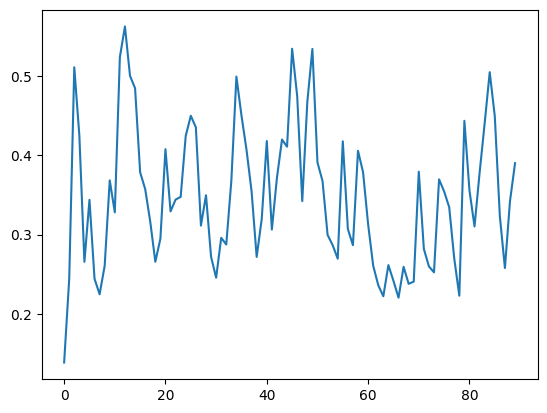

In [12]:
plt.plot(x[order:])